In [1]:
import torch
import random
from pathlib import Path
import matplotlib.pyplot as plt
from ultralytics import YOLO, settings
import time

In [2]:

print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))
print("CUDA:", torch.version.cuda)

True
NVIDIA GeForce RTX 4060 Laptop GPU
CUDA: 12.1


In [3]:
current_dir=Path.cwd()
if current_dir.name=="notebook":
    project_root=current_dir.parent
else:
    project_root=current_dir
models_dir=project_root/"models"
output_dir=project_root/"outputs"/"yolo"
output_dir.mkdir(parents=True, exist_ok=True)
models_dir.mkdir(parents=True, exist_ok=True)
settings.update({
    "weights_dir": str(models_dir)
})

In [ ]:


# train
pretrained_path=project_root/"models"/"yolo11s.pt"
model=YOLO(str(pretrained_path))
start=time.perf_counter()
model.train(
    data=str(project_root/"data.yaml"),
    epochs=100,
    imgsz=640,
    batch=8,
    device=0,
    patience=15,
    amp=True,
    project=str(output_dir),
    name="Rail_Defect_Detect",
    cache=True,
    workers=8
)

elapsed=time.perf_counter()-start
print(f"Training time: {elapsed/60:.2f} minutes.")

New https://pypi.org/project/ultralytics/8.4.165 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.161  Python-3.12.9 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=True, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=c:\Users\Kun Bi\Desktop\rail_yolo_object_identification\data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ra

In [5]:
# # load best model
best_model=YOLO(model.trainer.best)

In [6]:
# Evaluate on test dataset
metrics=best_model.val(
    data=str(project_root/"data.yaml"),
    split="test",
    imgsz=640,
    device=0,
    project=str(output_dir),
    plots=True,
    name="Rail_Defect_validation"
    )


Ultralytics 8.4.161  Python-3.12.9 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
YOLO11s summary (fused): 100 layers, 9,416,670 parameters, 0 gradients, 21.4 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 85.640.1 MB/s, size: 74.7 KB)
val: Scanning C:\Users\Kun Bi\Desktop\rail_yolo_object_identification\data\test\labels.cache... 300 images, 13 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 310/310  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 20/20 1.2it/s 16.9s0.1s
                   all        310       1494      0.411      0.443      0.401      0.156
           Corrugation         92        298      0.428      0.374      0.367      0.143
                Cracks         84        234      0.415      0.184      0.212      0.068
               Flaking         70        157      0.311      0.255      0.206     0.0789
                Joints          8         11      0.379      0.909      0.676

In [7]:
print(f"Precision: {metrics.box.mp}")
print(f"Recall: {metrics.box.mr}")
print(f"mAP50: {metrics.box.map50}")
print(f"mAP50-95: {metrics.box.map}")

Precision: 0.41055994398227247
Recall: 0.44338212475538735
mAP50: 0.4008543114295943
mAP50-95: 0.1558553026469211


In [8]:
print(metrics.box.maps)

[    0.15586     0.14329    0.067993    0.078885      0.3022     0.37731     0.16855     0.12958    0.081899    0.052996]


In [9]:
# make prediction on 5 test images
test_dir=Path("../data/test/images")
test_images=[
    image for image in test_dir.iterdir()
    if image.suffix.lower() in [".jpg"]
]
random.seed(42)

sample_images=random.sample(
    test_images,
    min(5, len(test_images))
)

sample_images

[WindowsPath('../data/test/images/20231018_113043_mp4-0268_jpg.rf.308f8ac457fb8a59cc090a6335f99555.jpg'),
 WindowsPath('../data/test/images/20231018_112728_mp4-0214_jpg.rf.56f3f591495243dbb3f823786c603227.jpg'),
 WindowsPath('../data/test/images/Rail_1_mp4-0029_jpg.rf.b99d45a808add36cfb5b8c3ababcc9e1.jpg'),
 WindowsPath('../data/test/images/20231018_120709_mp4-0181_jpg.rf.b8bfc6509d5260d40b294e7bf3eb213b.jpg'),
 WindowsPath('../data/test/images/20231018_114952_mp4-0488_jpg.rf.35b5626dd30141138e258a05b592c9d0.jpg')]

In [10]:
#### Make prediction

In [11]:
results=best_model.predict(
    source=[str(image) for image in sample_images],
    imgsz=640,
    conf=0.25,
    device=0,
    project=str(output_dir),
    name="Rail_Defect_Predictions"
)


0: 640x640 3 Spallings, 4.3ms
1: 640x640 6 Corrugations, 2 Flakings, 2 Spallings, 4.3ms
2: 640x640 5 Shellings, 4.3ms
3: 640x640 (no detections), 4.3ms
4: 640x640 (no detections), 4.3ms
Speed: 2.4ms preprocess, 4.3ms inference, 0.8ms postprocess per image at shape (1, 3, 640, 640)


In [12]:
#### Display results

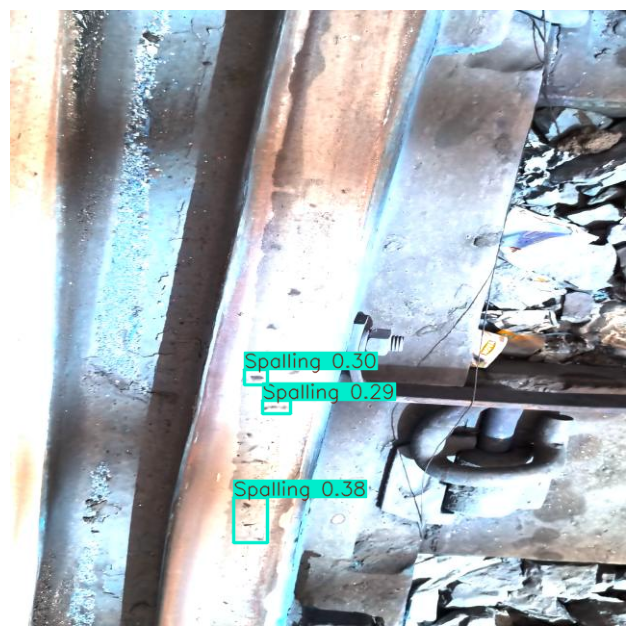

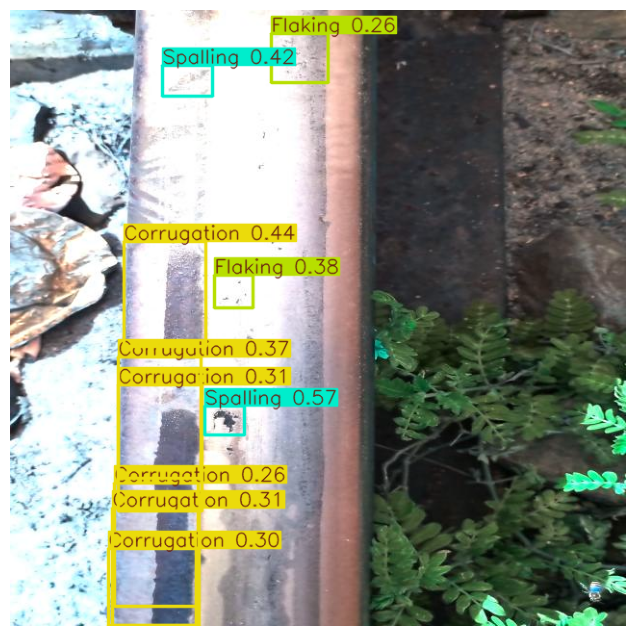

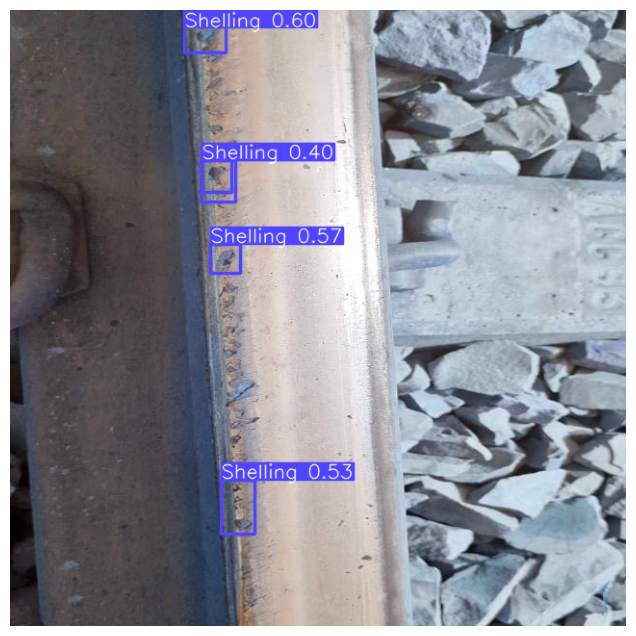

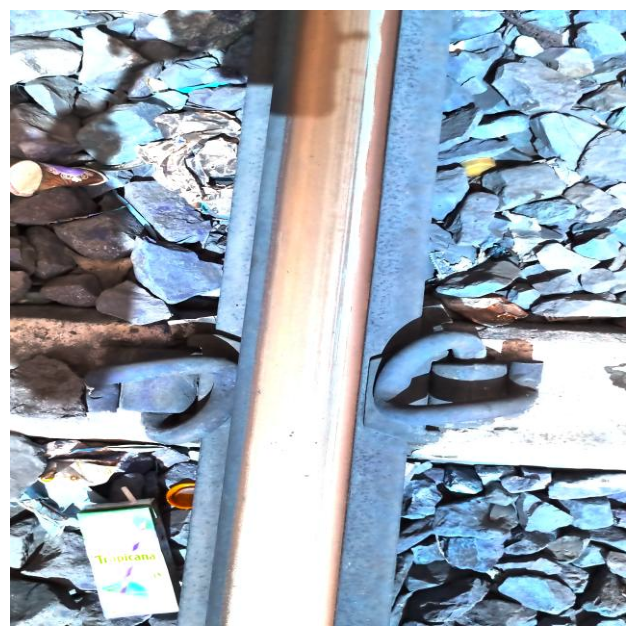

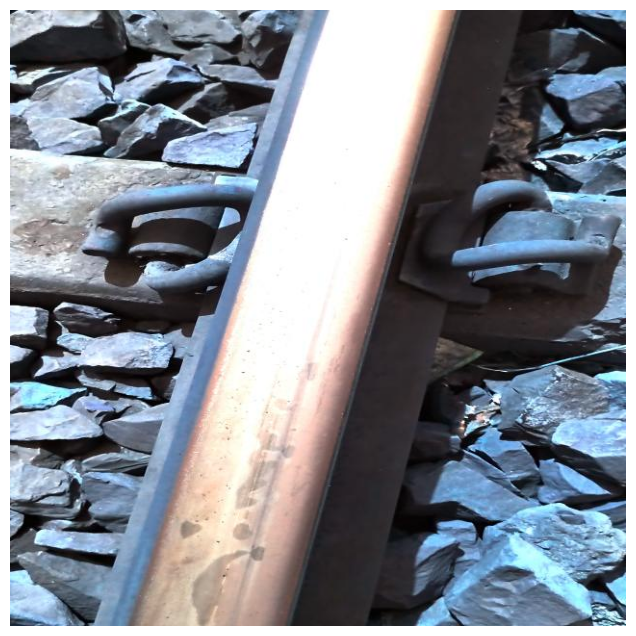

In [13]:
for result in results:
    predicted_images=result.plot()
    plt.figure(figsize=(10,8))
    plt.imshow(predicted_images[..., ::1])
    plt.axis("off")
    plt.show()

In [15]:
import pandas as pd

df = pd.read_csv("../outputs/yolo/Rail_Defect_Detect-5/results.csv")

print("Epochs completed:", len(df))
print(df.tail())

Epochs completed: 18
    epoch     time  train/box_loss  train/cls_loss  train/dfl_loss  \
13     14  1274.08         2.10220         2.02360         1.66952   
14     15  1358.90         2.08940         1.99717         1.66520   
15     16  1445.09         2.07849         1.96828         1.65320   
16     17  1531.84         2.06003         1.94438         1.64261   
17     18  1616.07         2.04531         1.92774         1.64156   

    metrics/precision(B)  metrics/recall(B)  metrics/mAP50(B)  \
13               0.41035            0.36149           0.31657   
14               0.38590            0.38890           0.33441   
15               0.39753            0.37951           0.31120   
16               0.42960            0.37762           0.32217   
17               0.38816            0.39756           0.33892   

    metrics/mAP50-95(B)  val/box_loss  val/cls_loss  val/dfl_loss    lr/pg0  \
13              0.11903       2.20604       2.15035       1.72211  0.000530   
14       